# Gruppen Abgabe

Die besten CNN-Modelle der jeweiligen Gruppenmitglieder werden geladen und einzeln bewertet.

- Dateiformat ist .keras
- TensorFlow / Keras Version: 2.14
- Alle Modelle erwarten Eingaben der Form `(28, 28, 1)` und sind auf normalisierten Daten (0 - 1) trainiert

Anschließend werden die Modelle mit verschiedenen Ensemble Verfahren zu neuen Modellen zusammengeführt.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras


print("tensorflow:", tf.__version__)
print("keras:", keras.__version__)

2026-04-11 22:04:50.553026: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 22:04:53.306808: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-11 22:05:00.823038: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-11 22:05:00.823080: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-11 22:05:00.859620: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

tensorflow: 2.14.0
keras: 2.14.0


## MNIST Testdaten laden und vorverarbeiten


In [3]:
_, (x_test, y_test) = keras.datasets.mnist.load_data()

x_test = x_test.astype('float32') / 255.0
x_test = x_test[..., np.newaxis]

print(f"Test Datensätze : {x_test.shape}")
print(f"Wertebereich : [{x_test.min():.2f}, {x_test.max():.2f}]")
print(f"Klassen : {np.unique(y_test)}")

11490434/11490434 [==============================] - 1s 0us/step
Test Datensätze : (10000, 28, 28, 1)
Wertebereich : [0.00, 1.00]
Klassen : [0 1 2 3 4 5 6 7 8 9]


## Modelle laden


In [4]:
main_path = "Besten Modelle"

all_models = {}

all_models["Vincent"] = keras.models.load_model(os.path.join(main_path, "CNN_Vincent.keras"))
all_models["Elma"] = keras.models.load_model(os.path.join(main_path, "CNN_Elma.keras"))
all_models["Katarina"] = keras.models.load_model(os.path.join(main_path, "CNN_Katarina.keras"))
all_models["Ilker"] = keras.models.load_model(os.path.join(main_path, "CNN_Ilker.keras"))
all_models["Jana"] = keras.models.load_model(os.path.join(main_path, "CNN_Jana.keras"))

print(f"\nGesamtanzahl geladener Modelle: {len(all_models)}")


Gesamtanzahl geladener Modelle: 5


# Einzelbewertung


In [5]:
single_results = {}

## Ilker


In [7]:
model = all_models["Ilker"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Ilker"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9947
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (No

## Jana


In [6]:
model = all_models["Jana"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Jana"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9955
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9216      
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (No

## Elma


In [8]:
model = all_models["Elma"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Elma"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9939
Model: "cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 32)        9248      
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 32)        0         
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 conv_4 (Conv2D)             (Non

## Katarina


In [9]:
model = all_models["Katarina"]
try:
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
except ValueError:
    preds = model.predict(x_test, verbose=0)
    if preds.ndim == 2 and preds.shape[1] > 1:
        acc = float(np.mean(np.argmax(preds, axis=1) == y_test))
    else:
        acc = float(np.mean((preds.ravel() > 0.5).astype(int) == y_test))

single_results["Katarina"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9909
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (No

## Vincent


In [10]:
model = all_models["Vincent"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Vincent"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9947
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 64)        640       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 64)        256       
 chNormalization)             

## Einzelbewertung Zusammenfassung



Durchschnittliche Accuracy : 0.9939


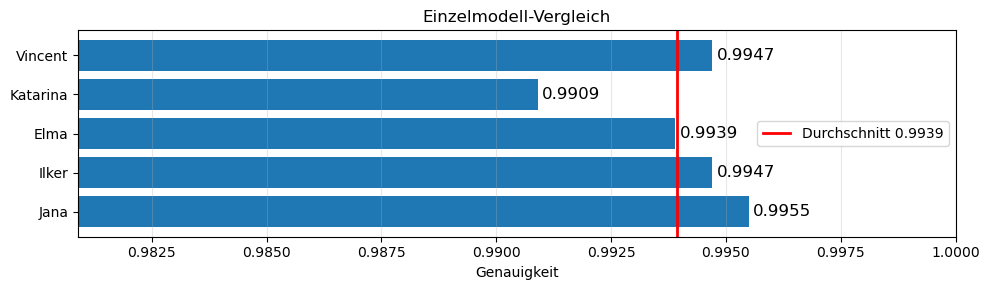

In [12]:
avg_acc = np.mean(list(single_results.values()))
print(f"\nDurchschnittliche Accuracy : {avg_acc:.4f}")

results_max = np.max(list(single_results.values()))

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.barh(list(single_results.keys()), list(single_results.values()))

x_min = min(single_results.values()) - 0.01
x_max = 1.0

ax.set_xlim(x_min, x_max)
ax.axvline(avg_acc, color="red", linewidth=2, label=f"Durchschnitt {avg_acc:.4f}")

for bar, val in zip(bars, single_results.values()):
    ax.text(bar.get_width() + (x_max - x_min) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=12)

ax.set_xlabel("Genauigkeit")
ax.set_title("Einzelmodell-Vergleich")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Ensemble (Grppenbewertung)


## Majority Voting Ensemble

Jedes Modell gibt eine Klasse aus. Die Klasse mit den meisten Stimmen gewinnt.
Bei Stimmengleichheit wird die Klasse mit der höchsten durchschnittlichen Wahrscheinlichkeit gewählt.


In [13]:
all_probs = [model.predict(x_test, verbose=0) for model in all_models.values()]

predictions_stack = np.array(all_probs)       
hard_preds        = np.argmax(predictions_stack, axis=2) 
votes             = hard_preds.T              

avg_probs_stack = predictions_stack.mean(axis=0)

majority_preds = np.array([
    np.bincount(row, minlength=10).argmax()
    if np.bincount(row, minlength=10).max() > 1
    else np.argmax(avg_probs_stack[i])
    for i, row in enumerate(votes)
])

acc_majority = float(np.mean(majority_preds == y_test))
print(f"Majority Voting Ergebnis: {acc_majority:.4f}")

Majority Voting Ergebnis: 0.9958


## Soft Voting Ensemble

Alle Modelle liefern Wahrscheinlichkeitsvektoren. Diese werden gemittelt und die Klasse mit der höchsten durchschnittlichen Wahrscheinlichkeit gewählt.


In [14]:
soft_avg_probs = predictions_stack.mean(axis=0)   # (10000, 10)
soft_preds     = np.argmax(soft_avg_probs, axis=1)

acc_soft = float(np.mean(soft_preds == y_test))
print(f"Soft Voting Ergebnis     : {acc_soft:.4f}")

Soft Voting Ergebnis     : 0.9961


## Weighted Average Voting Ensemble

Jedes Modell wird nach seiner Einzelmodell-Genauigkeit gewichtet. Bessere Modelle haben entsprechend mehr Einfluss auf die finale Vorhersage.


In [15]:
model_names = list(all_models.keys())
# Build accuracies aligned with the order of `all_models` (fallback to avg_acc if missing)
model_accs = np.array([single_results.get(name, avg_acc) for name in model_names])

model_accs_sum = np.sum(model_accs)
if model_accs_sum == 0:
    weights = np.ones_like(model_accs) / len(model_accs)
else:
    weights = model_accs / model_accs_sum
# predictions_stack shape: (n_models, n_samples, n_classes)
# Ensure weights shape matches n_models and broadcast correctly
weights_broadcast = weights.reshape((-1, 1, 1))
weighted_probs = np.sum(predictions_stack * weights_broadcast, axis=0)
weighted_preds = np.argmax(weighted_probs, axis=1)

print(f"\nGewichte der Modelle:")
for name, w in zip(model_names, weights):
    print(f"  {name:50s}  w={w:.4f}")

acc_weighted = float(np.mean(weighted_preds == y_test))
print(f"Weighted Voting Ergebnis: {acc_weighted:.4f}")




Gewichte der Modelle:
  Vincent                                             w=0.2002
  Elma                                                w=0.2000
  Katarina                                            w=0.1994
  Ilker                                               w=0.2002
  Jana                                                w=0.2003
Weighted Voting Ergebnis: 0.9961


## Ensemble Zusammenfassung


In [16]:
print(f"  Anzahl Modelle            : {len(all_models)}")
print("---------------------------------------")
print(f"  Schlechtestes Einzelmodell: {np.min(list(single_results.values())):.4f}")
print(f"  Bestes Einzelmodell       : {np.max(list(single_results.values())):.4f}")
print(f"  Durchschnitt Einzelmodelle: {avg_acc:.4f}")
print("---------------------------------------")
print(f"  Majority Voting Ensemble  : {acc_majority:.4f}")
print(f"  Soft Voting Ensemble      : {acc_soft:.4f}")
print(f"  Weighted Voting Ensemble  : {acc_weighted:.4f}")

  Anzahl Modelle            : 5
---------------------------------------
  Schlechtestes Einzelmodell: 0.9909
  Bestes Einzelmodell       : 0.9955
  Durchschnitt Einzelmodelle: 0.9939
---------------------------------------
  Majority Voting Ensemble  : 0.9958
  Soft Voting Ensemble      : 0.9961
  Weighted Voting Ensemble  : 0.9961


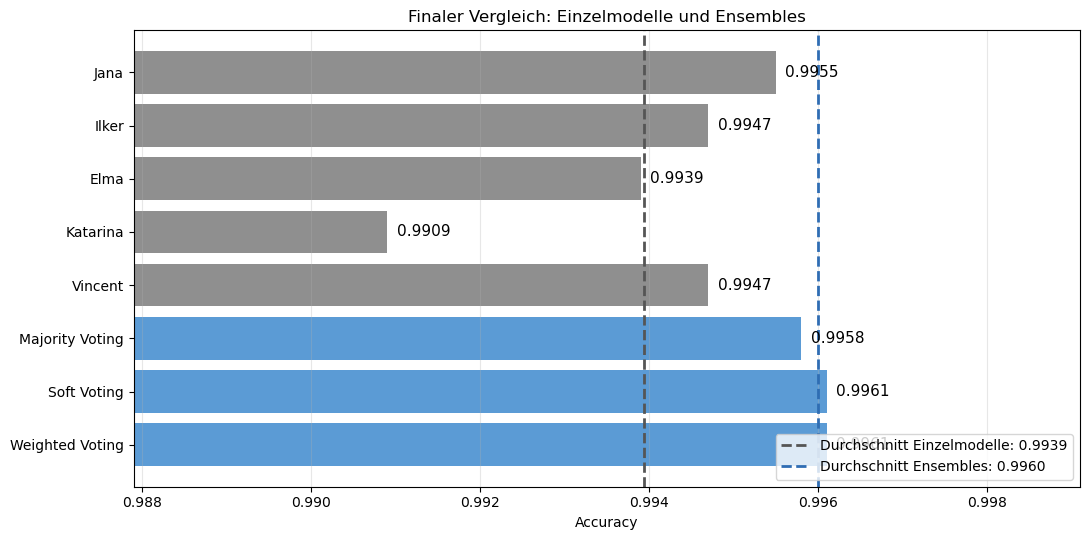

In [17]:
single_plot_results = {name: float(acc) for name, acc in single_results.items()}
ensemble_plot_results = {
    "Majority Voting": float(acc_majority),
    "Soft Voting": float(acc_soft),
    "Weighted Voting": float(acc_weighted),
}

comparison_results = {**single_plot_results, **ensemble_plot_results}
labels = list(comparison_results.keys())
values = np.array(list(comparison_results.values()))
colors = ["#8f8f8f"] * len(single_plot_results) + ["#5b9bd5"] * len(ensemble_plot_results)

avg_single_models = float(np.mean(list(single_plot_results.values())))
avg_ensembles = float(np.mean(list(ensemble_plot_results.values())))

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(labels, values, color=colors)

x_min = max(0.0, values.min() - 0.003)
x_max = min(1.0, values.max() + 0.003)
ax.set_xlim(x_min, x_max)
ax.invert_yaxis()

for bar, value in zip(bars, values):
    ax.text(
        value + (x_max - x_min) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=11,
    )

ax.axvline(
    avg_single_models,
    color="#555555",
    linestyle="--",
    linewidth=2,
    label=f"Durchschnitt Einzelmodelle: {avg_single_models:.4f}",
)
ax.axvline(
    avg_ensembles,
    color="#2f6db3",
    linestyle="--",
    linewidth=2,
    label=f"Durchschnitt Ensembles: {avg_ensembles:.4f}",
)

ax.set_xlabel("Accuracy")
ax.set_title("Finaler Vergleich: Einzelmodelle und Ensembles")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()